# Install libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import os

plt.style.use('ggplot')
pd.set_option('display.max_columns',200)

DATASET_DIR = os.path.join(os.getcwd(), '..', 'data')

## Creating DataFrame

In [3]:
df = pd.read_csv(os.path.join(DATASET_DIR, 'Delivery_Logistics.csv'))
df.head(10)

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600
5,250.99,amazon logistics,documents,ev bike,express,west,rainy,48.4,33.15,1970-01-01 00:00:00.000000004,1970-01-01 00:00:00.000000002,yes,delayed,3,391.4500
6,250.99,delhivery,groceries,scooter,same day,central,clear,198.3,43.79,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1222.8700
7,250.99,xpressbees,fragile items,van,same day,north,cold,114.6,42.63,1970-01-01 00:00:00.000000004,1970-01-01 00:00:00.000000008,no,delivered,3,800.8900
8,250.99,blue dart,clothing,van,same day,south,hot,142.4,14.06,1970-01-01 00:00:00.000000005,1970-01-01 00:00:00.000000008,no,delivered,5,854.1800
9,250.99,delhivery,pharmacy,truck,same day,east,foggy,47.1,29.28,1970-01-01 00:00:00.000000003,1970-01-01 00:00:00.000000008,no,delivered,5,423.3400


# Data Understanding

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_id          25000 non-null  float64
 1   delivery_partner     25000 non-null  object 
 2   package_type         25000 non-null  object 
 3   vehicle_type         25000 non-null  object 
 4   delivery_mode        25000 non-null  object 
 5   region               25000 non-null  object 
 6   weather_condition    25000 non-null  object 
 7   distance_km          25000 non-null  float64
 8   package_weight_kg    25000 non-null  float64
 9   delivery_time_hours  25000 non-null  object 
 10  expected_time_hours  25000 non-null  object 
 11  delayed              25000 non-null  object 
 12  delivery_status      25000 non-null  object 
 13  delivery_rating      25000 non-null  int64  
 14  delivery_cost        25000 non-null  float64
dtypes: float64(4), int64(1), object(10)


We have 15 columns and 2500 rows without missing values

In [5]:
df.duplicated().sum()

np.int64(0)

We have no duplicated values

In [6]:
df.describe()

,delivery_id,distance_km,package_weight_kg,delivery_rating,delivery_cost
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,12500.500000,150.390436,25.145898,3.666000,864.944579
std,7212.732314,86.409745,14.368663,1.149964,435.712593
min,250.990000,3.600000,0.670000,1.000000,95.667400
25%,6250.750000,75.900000,12.680000,3.000000,490.800000
50%,12500.500000,151.000000,25.145000,4.000000,867.535000
75%,18750.250000,224.900000,37.660000,5.000000,1237.910000
max,24750.010000,297.100000,49.520000,5.000000,1632.720600


In [7]:
df.describe(include = 'object')

,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,delivery_time_hours,expected_time_hours,delayed,delivery_status
count,25000,25000,25000,25000,25000,25000,25000,25000,25000,25000
unique,9,9,6,4,5,6,20,9,2,3
top,xpressbees,fragile items,ev bike,two day,west,foggy,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000016,no,delivered
freq,2826,2848,4218,6302,5095,4219,3118,6302,18331,18331


In [8]:
df['delivery_partner'].value_counts()

delivery_partner
xpressbees          2826
fedex               2818
dhl                 2802
ekart               2801
blue dart           2798
delhivery           2786
shadowfax           2736
ecom express        2722
amazon logistics    2711
Name: count, dtype: int64

In [9]:
df['package_type'].value_counts()

package_type
fragile items       2848
pharmacy            2810
documents           2805
automobile parts    2795
electronics         2792
clothing            2767
furniture           2746
cosmetics           2744
groceries           2693
Name: count, dtype: int64

In [10]:
df['vehicle_type'].value_counts()

vehicle_type
ev bike    4218
van        4187
scooter    4174
bike       4160
truck      4145
ev van     4116
Name: count, dtype: int64

In [11]:
df['delivery_mode'].value_counts()

delivery_mode
two day     6302
same day    6279
express     6233
standard    6186
Name: count, dtype: int64

In [12]:
df['region'].value_counts()

region
west       5095
central    5060
south      4977
north      4949
east       4919
Name: count, dtype: int64

In [13]:
df['weather_condition'].value_counts()

weather_condition
foggy     4219
stormy    4198
rainy     4171
cold      4158
hot       4130
clear     4124
Name: count, dtype: int64

# Exporitary Data analysis

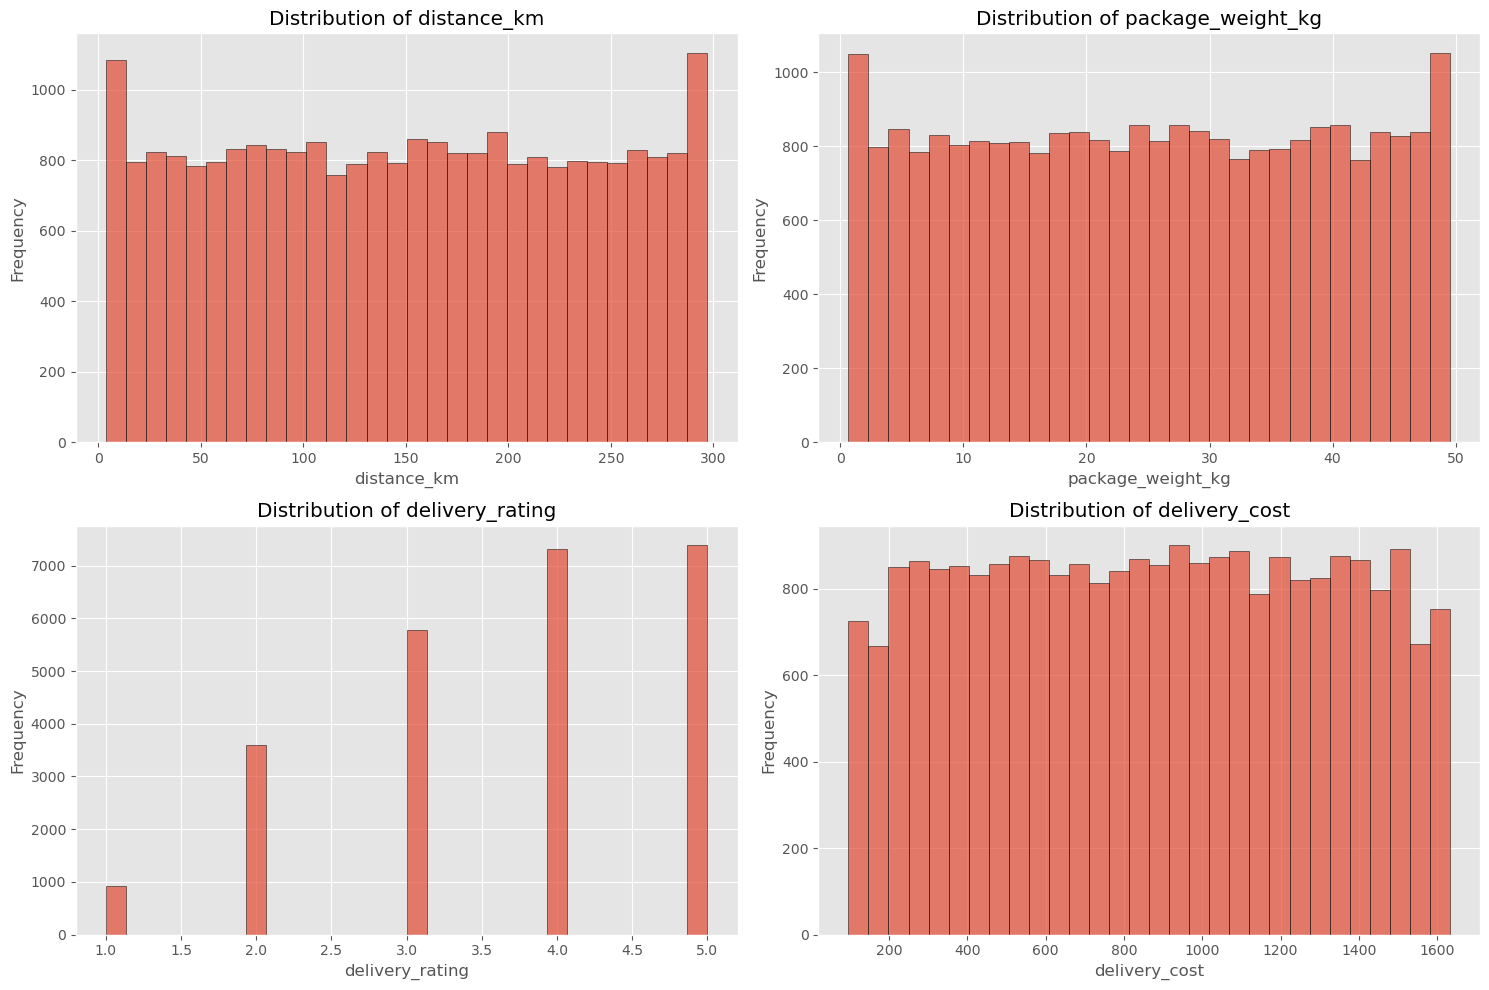

In [14]:
# UNIVARIATE ANALYSIS OF NUMERICAL VALUES
fig, axes = plt.subplots(2,2, figsize = (15,10))
numerical_cols = ['distance_km',	'package_weight_kg',	'delivery_rating',	'delivery_cost']

for i, col in enumerate(numerical_cols):
    row, col_idx = i // 2, i % 2
    axes[row, col_idx].hist(df[col], bins=30, alpha=0.7, edgecolor='black')
    axes[row, col_idx].set_title(f'Distribution of {col}')
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

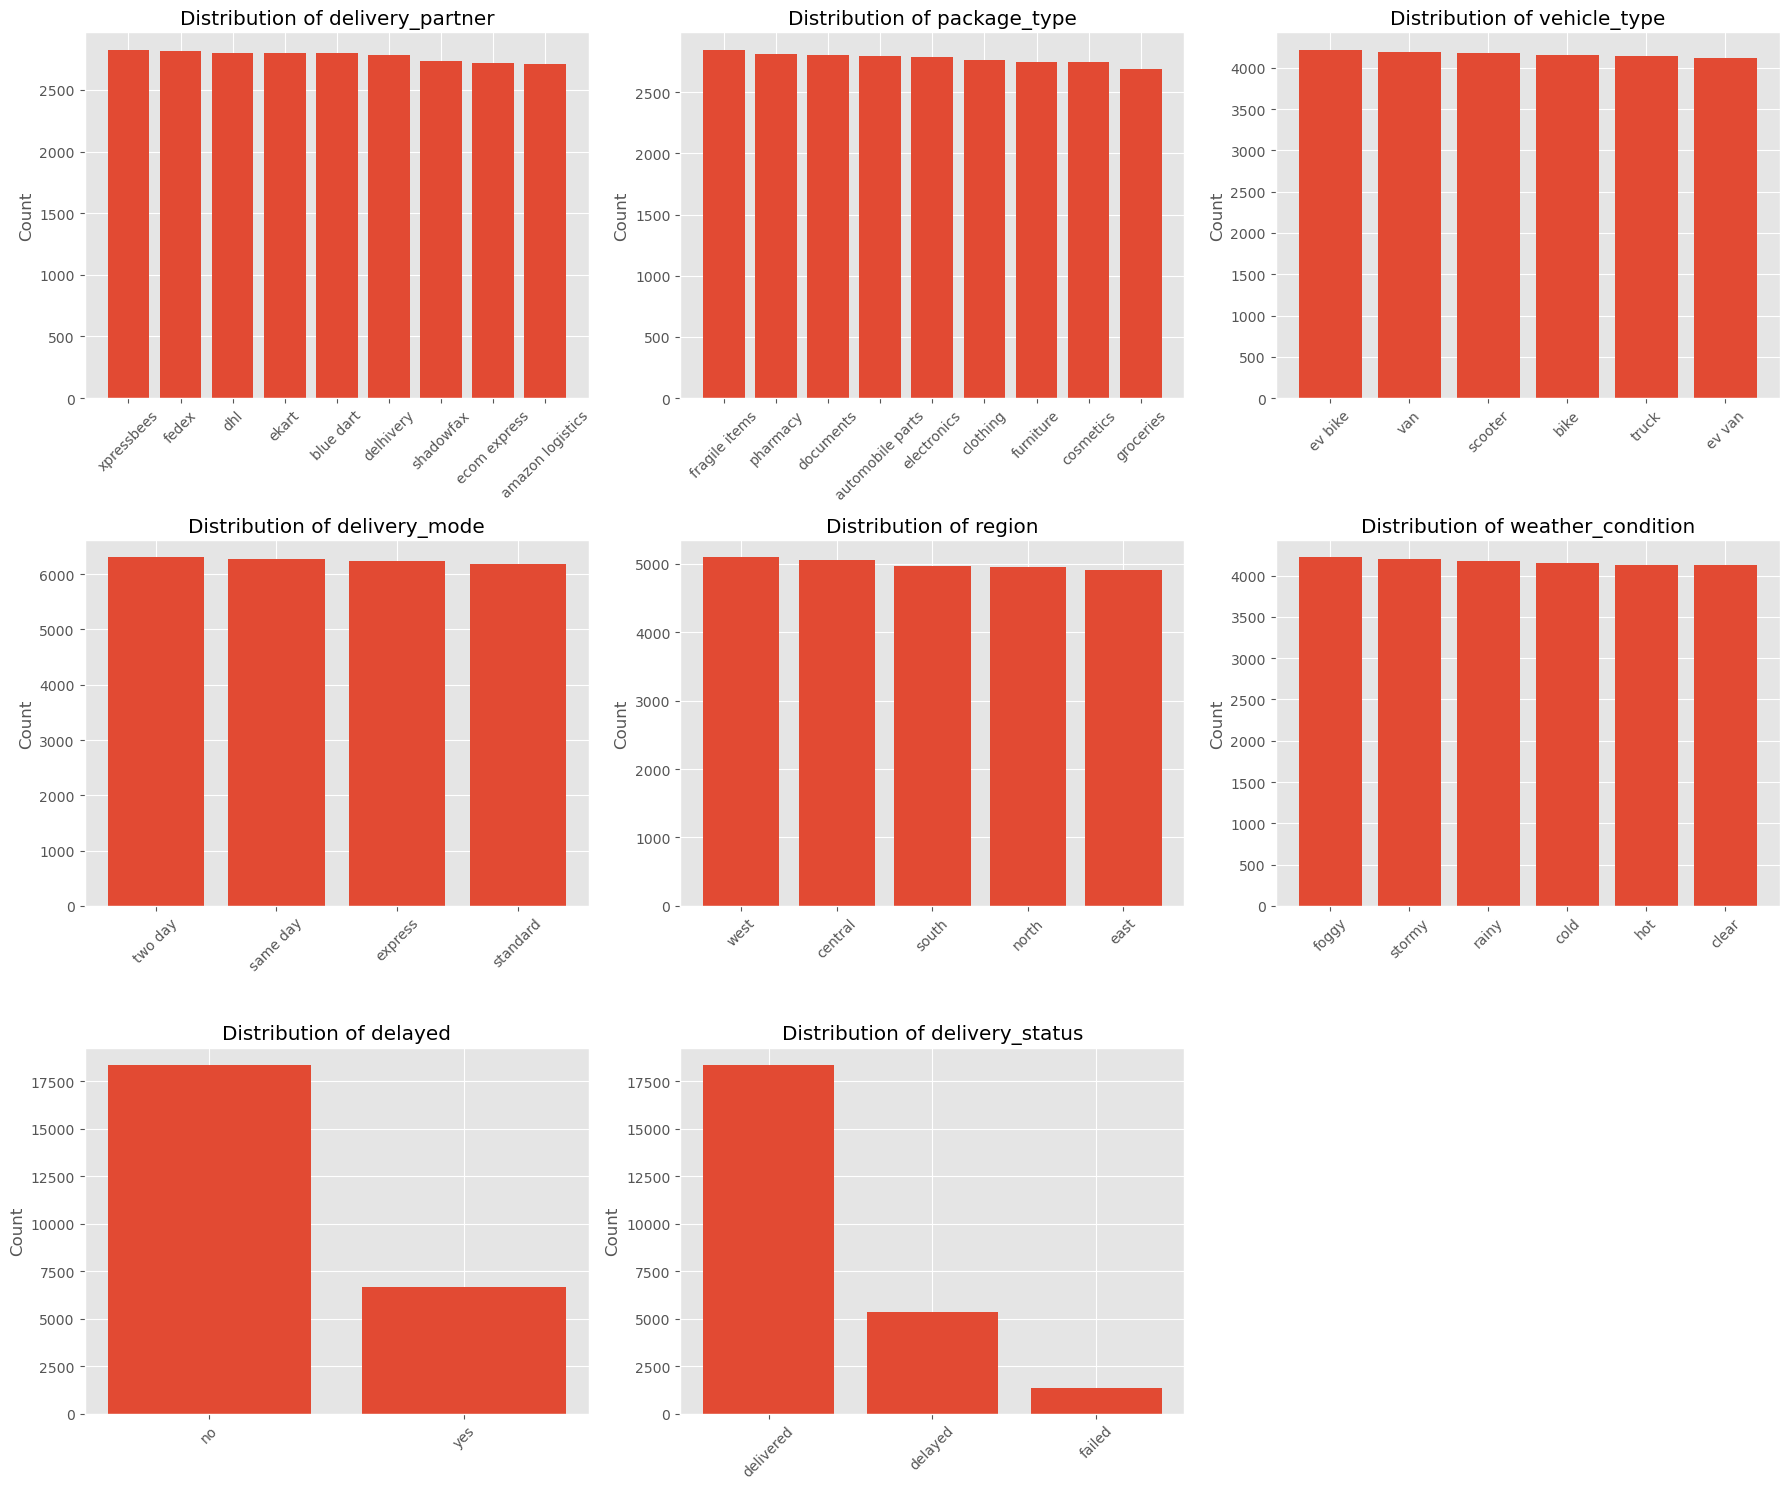

In [20]:
# UNIVARIATE ANALYSIS OF CATEGORICAL VALUES
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()
categorical_cols = ['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 
                   'region', 'weather_condition', 'delayed', 'delivery_status']

for i, col in enumerate(categorical_cols):
    value_counts = df[col].value_counts()
    axes[i].bar(value_counts.index, value_counts.values)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Count')

# Hide unused subplots
for i in range(len(categorical_cols), 9):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()


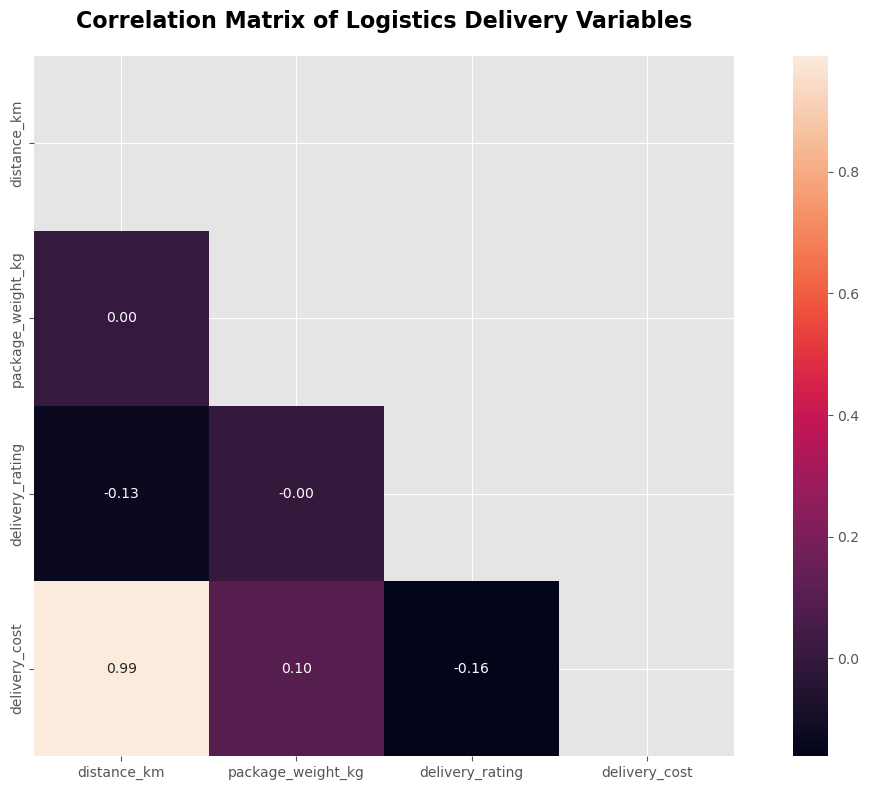

In [23]:
# Creating Correlation Analysis

plt.figure(figsize=(12,8))

# correlation matrix
matrix = df[numerical_cols].corr()

#heatmap
mask = np.triu(np.ones_like(matrix, dtype=bool))
sns.heatmap(matrix, mask=mask, annot=True, square=True, fmt='.2f')

plt.title('Correlation Matrix of Logistics Delivery Variables', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()



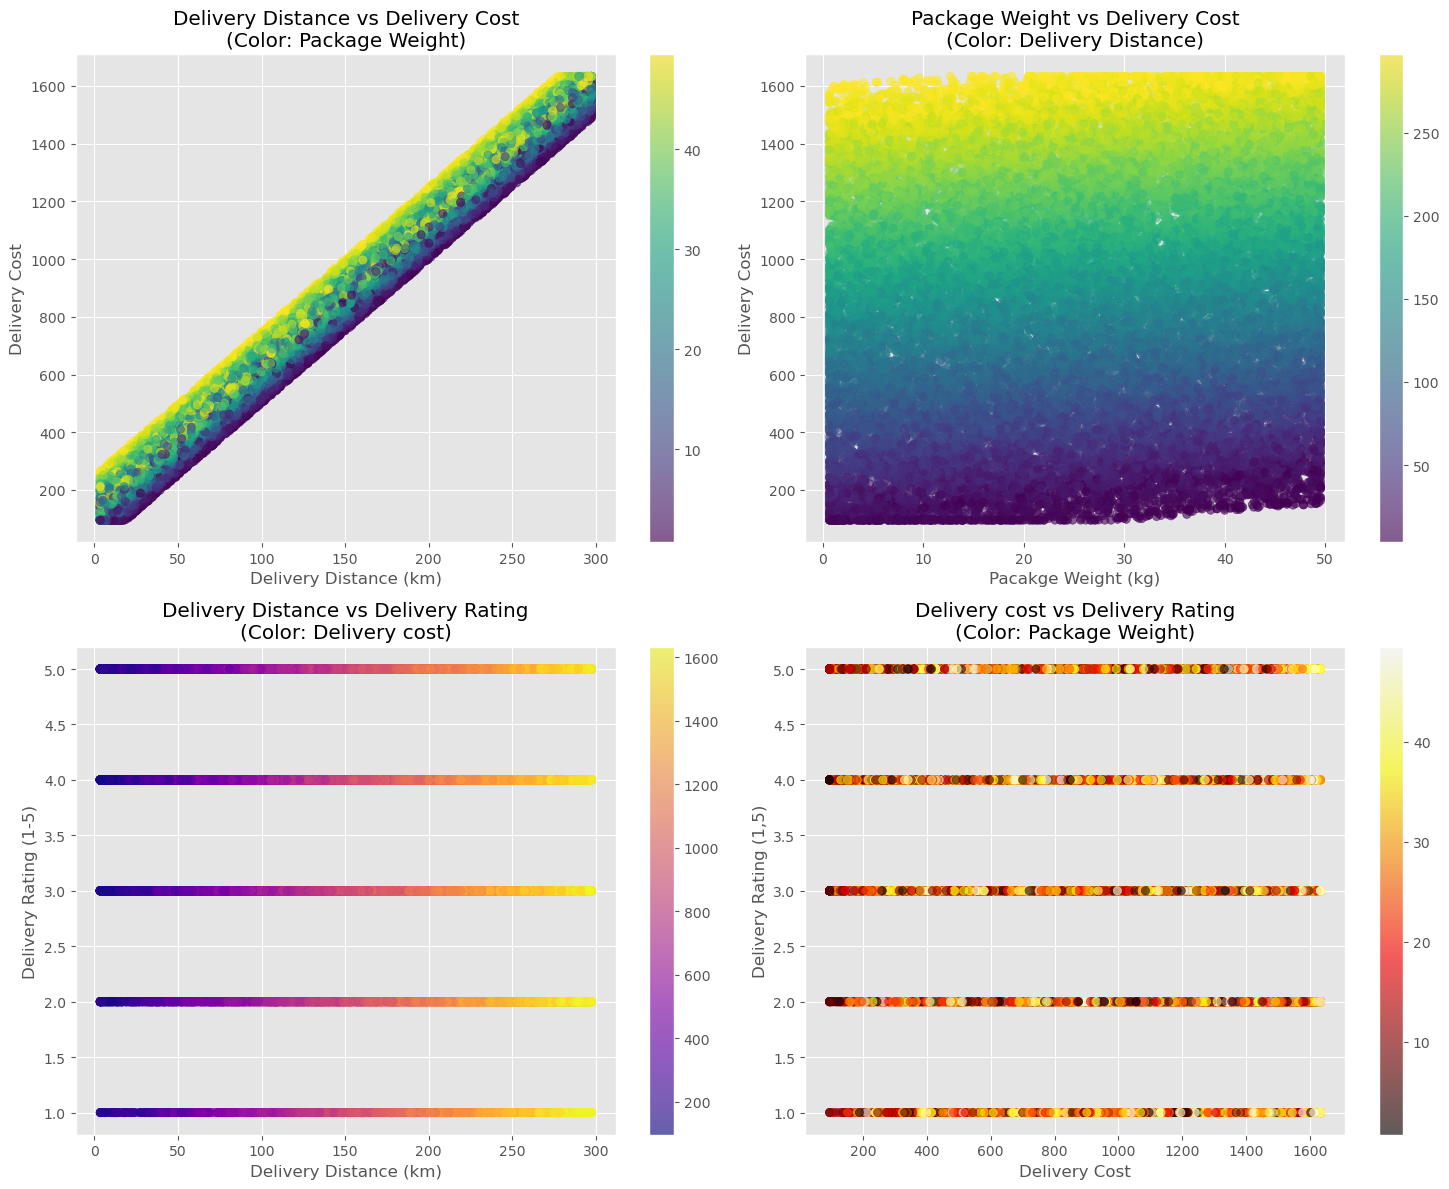

In [40]:
# Scatter plots 
fig, axes = plt.subplots(2, 2, figsize = (15,12))

# Delivery distance vs delivery cost
axes[0, 0].scatter(df['distance_km'], df['delivery_cost'], alpha=0.6, c=df['package_weight_kg'], cmap='viridis')
axes[0,0].set_xlabel('Delivery Distance (km)')
axes[0,0].set_ylabel('Delivery Cost')
axes[0,0].set_title('Delivery Distance vs Delivery Cost\n(Color: Package Weight)')
plt.colorbar(axes[0,0].collections[0], ax=axes[0,0])

# Package weight vs delivery cost
axes[0,1].scatter(df['package_weight_kg'], df['delivery_cost'], alpha=0.6, c=df['distance_km'], cmap='viridis')
axes[0,1].set_xlabel('Pacakge Weight (kg)')
axes[0,1].set_ylabel('Delivery Cost')
axes[0,1].set_title('Package Weight vs Delivery Cost\n(Color: Delivery Distance)')
plt.colorbar(axes[0,1].collections[0], ax=axes[0,1])

# Delivery Distance vs Delivery rating
axes[1,0].scatter(df['distance_km'], df['delivery_rating'], alpha=0.6, c=df['delivery_cost'], cmap='plasma')
axes[1,0].set_xlabel('Delivery Distance (km)')
axes[1,0].set_ylabel('Delivery Rating (1-5)')
axes[1,0].set_title('Delivery Distance vs Delivery Rating\n(Color: Delivery cost)')
plt.colorbar(axes[1,0].collections[0], ax=axes[1,0])

# Delivery Cost vs Delivery Rating
axes[1,1].scatter(df['delivery_cost'], df['delivery_rating'], alpha=0.6, c=df['package_weight_kg'], cmap='hot')
axes[1,1].set_xlabel('Delivery Cost')
axes[1,1].set_ylabel('Delivery Rating (1,5)')
axes[1,1].set_title('Delivery cost vs Delivery Rating\n(Color: Package Weight)')
plt.colorbar(axes[1,1].collections[0], ax=axes[1,1])

plt.tight_layout()
plt.show()

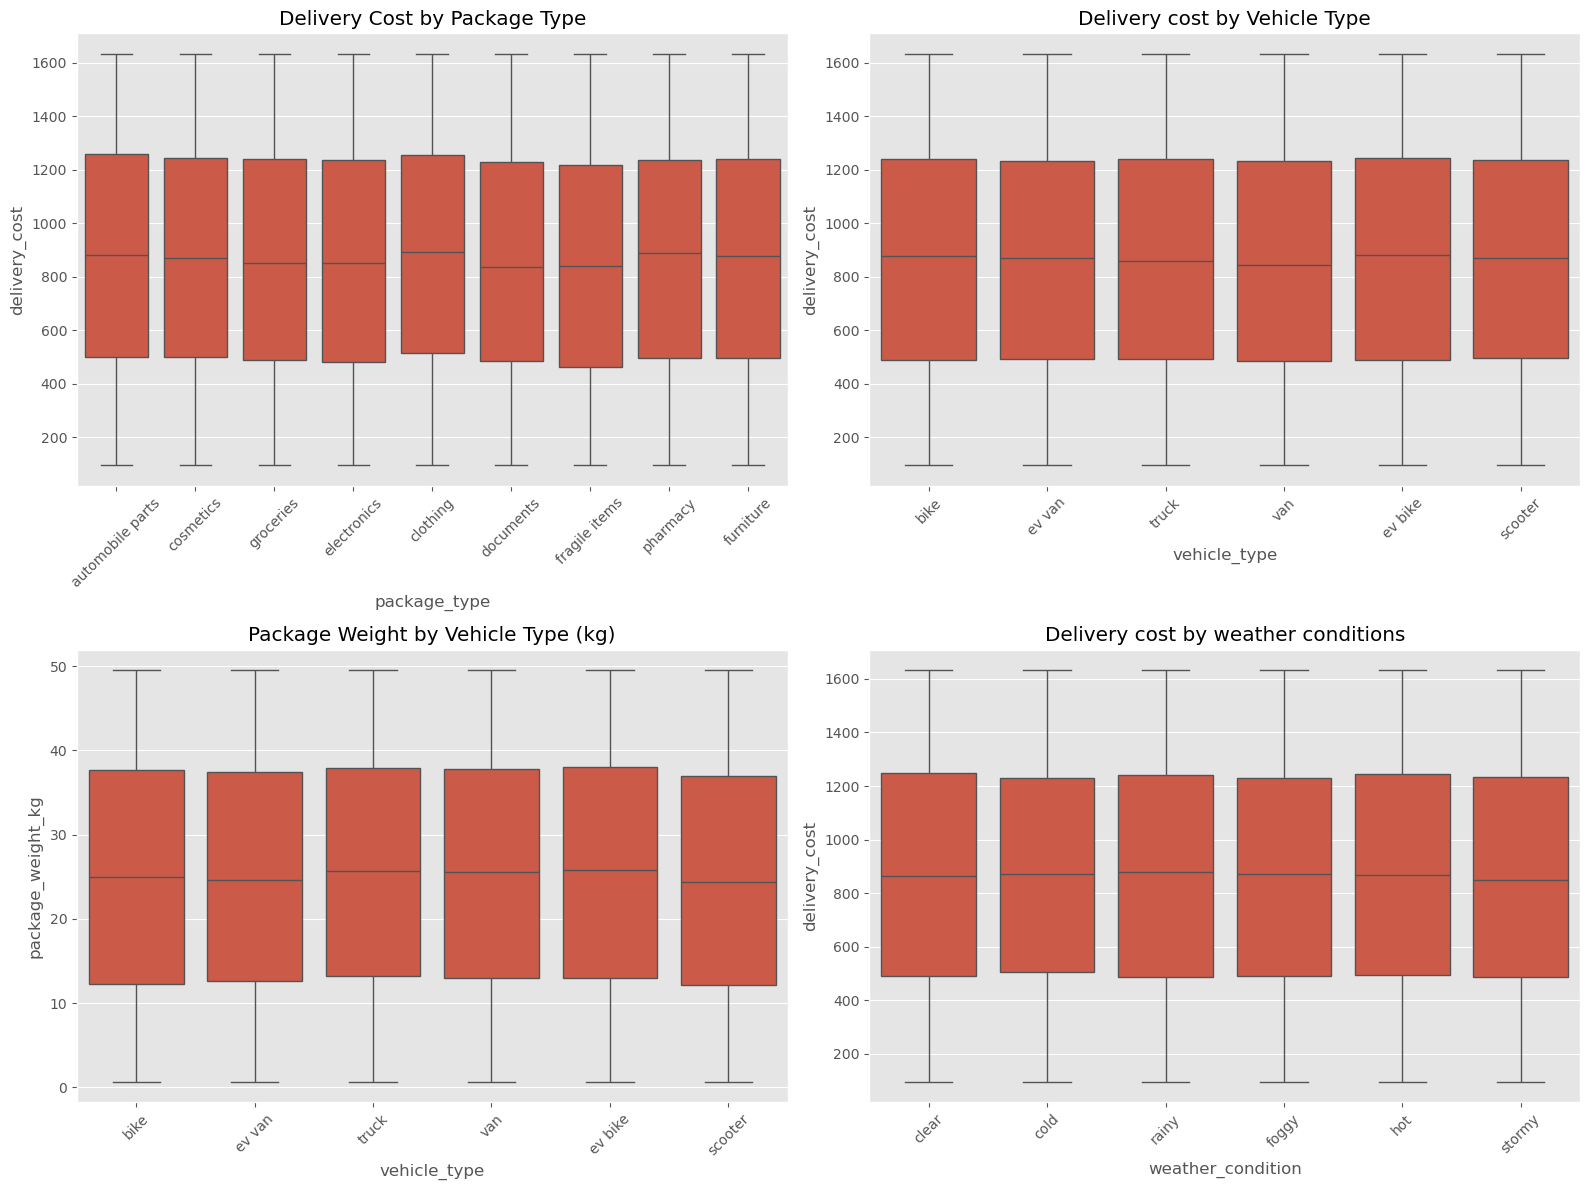

In [57]:
# BIVARIATE ANALYSIS - NUMERICAL VS CATEGORICAL

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Delivery cost by package type
sns.boxplot(data=df, x='package_type', y='delivery_cost', ax=axes[0,0])
axes[0,0].set_title('Delivery Cost by Package Type')
axes[0,0].tick_params(axis='x', rotation=45)

# Delivery cost by vehicle type
sns.boxplot(data=df, x='vehicle_type', y='delivery_cost', ax=axes[0,1])
axes[0,1].set_title('Delivery cost by Vehicle Type')
axes[0,1].tick_params(axis='x', rotation=45)

# Pacakge weight by vehicle type
sns.boxplot(data=df, x='vehicle_type', y='package_weight_kg', ax=axes[1,0])
axes[1,0].set_title('Package Weight by Vehicle Type (kg)')
axes[1,0].tick_params(axis='x', rotation=45)

# Distance by region
sns.boxplot(data=df, x='weather_condition', y='delivery_cost', ax=axes[1,1])
axes[1,1].set_title('Delivery cost by weather conditions')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

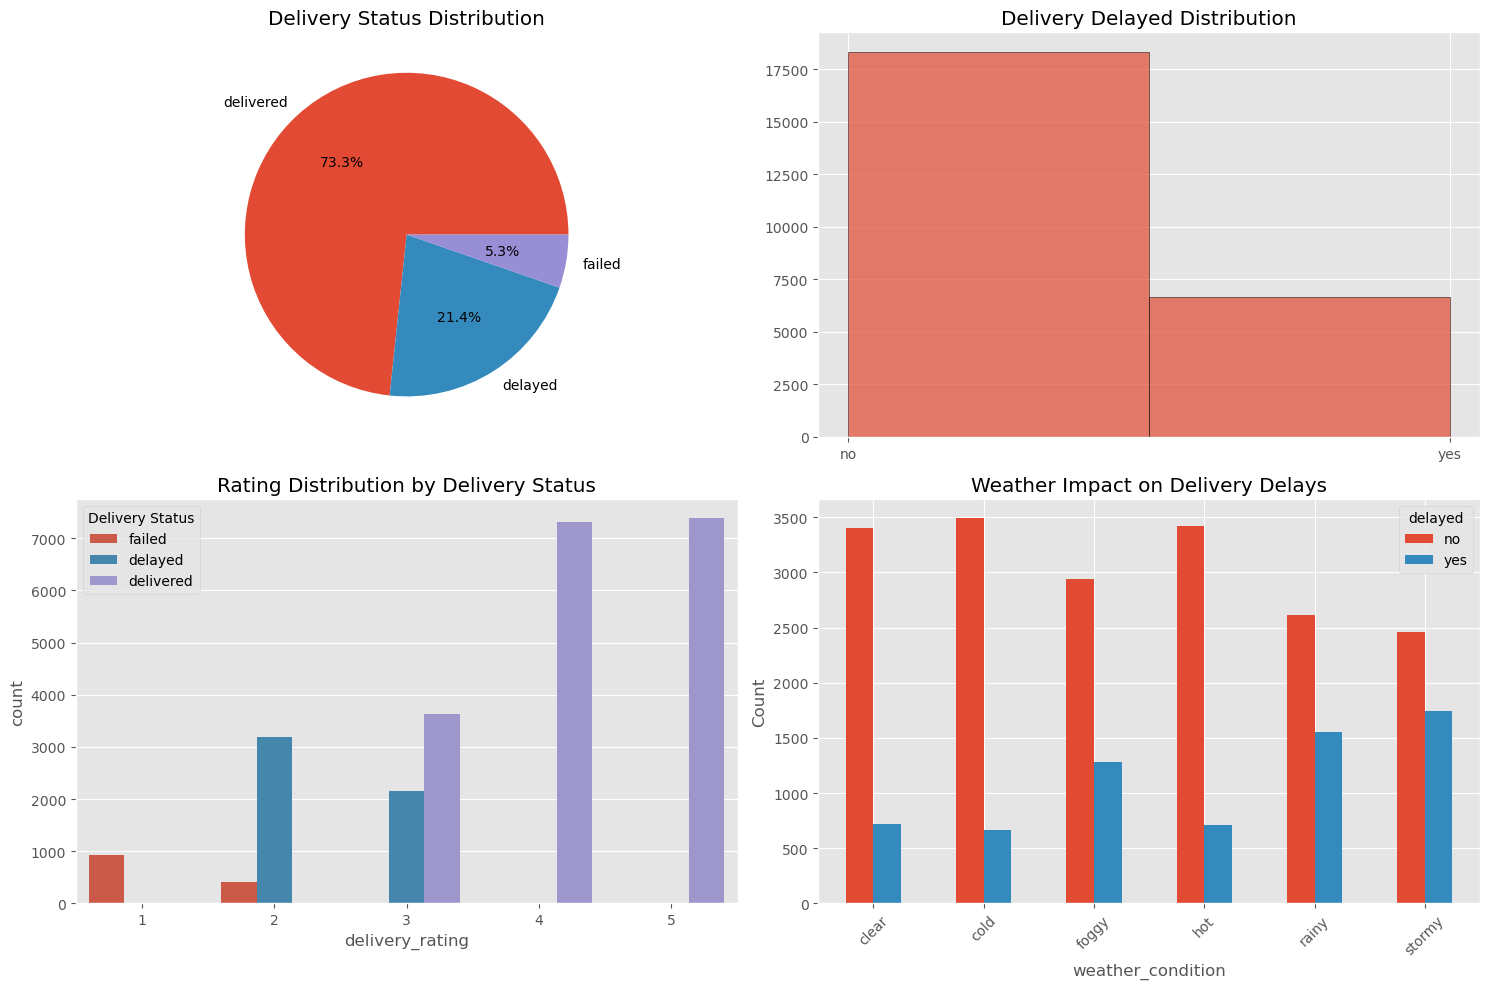

In [50]:
# DELIVERY PERFORMANCE ANALYSIS

fig, axes = plt.subplots(2, 2, figsize = (15,10))

status_counts = df['delivery_status'].value_counts()
axes[0,0].pie(status_counts.values, labels=status_counts.index, autopct = '%1.1f%%')
axes[0,0].set_title('Delivery Status Distribution')

axes[0,1].hist(df['delayed'], alpha=0.7, edgecolor='black', bins=2)
axes[0,1].set_title('Delivery Delayed Distribution')

sns.countplot(data=df, x='delivery_rating', hue='delivery_status', ax=axes[1,0])
axes[1,0].set_title('Rating Distribution by Delivery Status')
axes[1,0].legend(title='Delivery Status')

weather_delay = pd.crosstab(df['weather_condition'], df['delayed'])
weather_delay.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Weather Impact on Delivery Delays')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


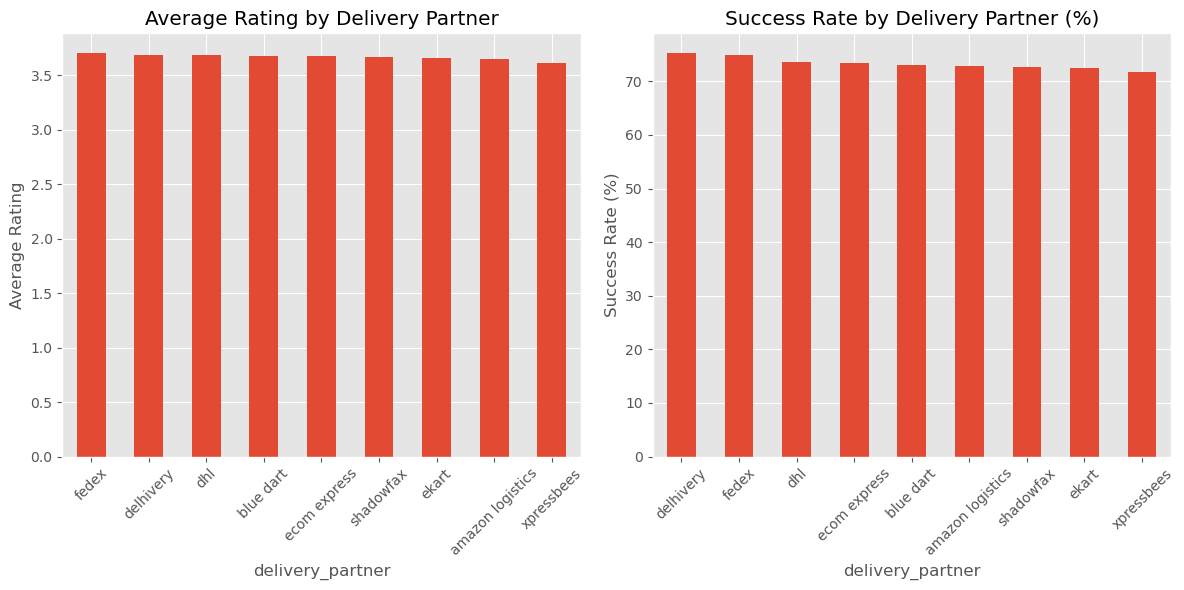

In [55]:
# PARTNER PERFORMANCE ANALYSIS
plt.figure(figsize=(12, 6))

# Average rating by delivery partner
partner_rating = df.groupby('delivery_partner')['delivery_rating'].mean().sort_values(ascending=False)
plt.subplot(1, 2, 1)
partner_rating.plot(kind='bar')
plt.title('Average Rating by Delivery Partner')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)

# Success rate by delivery partner
partner_success = df.groupby('delivery_partner')['delivery_status'].apply(
    lambda x: (x == 'delivered').mean() * 100
).sort_values(ascending=False)

plt.subplot(1, 2, 2)
partner_success.plot(kind='bar')
plt.title('Success Rate by Delivery Partner (%)')
plt.ylabel('Success Rate (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
